In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

data = pd.read_csv('milkproduction.csv', index_col = 'Month')

data.index = pd.DatetimeIndex(data.index).to_period('M')

data, test_set = data.truncate(after = "1975-06"), data.truncate(before = "1975-07")
print(data.tail().T)
print(test_set.T)

Month       1975-02  1975-03  1975-04  1975-05  1975-06
production      782      892      903      966      937
Month       1975-07  1975-08  1975-09  1975-10  1975-11  1975-12
production      896      858      817      827      797      843


(-1.689950246082003, 0.4362977091126895, 13, 148, {'1%': -3.4753253063120644, '5%': -2.881274703275226, '10%': -2.5772928360116873}, 1069.7468271630046)
       lb_stat      lb_pvalue
1   128.694108   7.911864e-30
2   223.818799   2.502449e-49
3   282.777814   5.306012e-61
4   317.614611   1.715775e-67
5   345.071586   2.014234e-72
6   366.138998   5.282911e-76
7   392.861344   8.095138e-81
8   427.288846   2.706712e-87
9   481.513369   5.210910e-98
10  565.139419  5.152227e-115


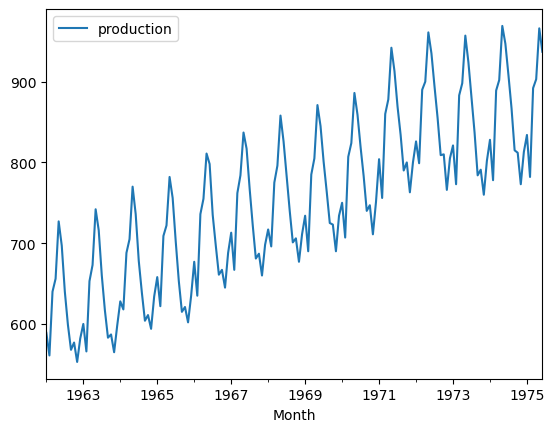

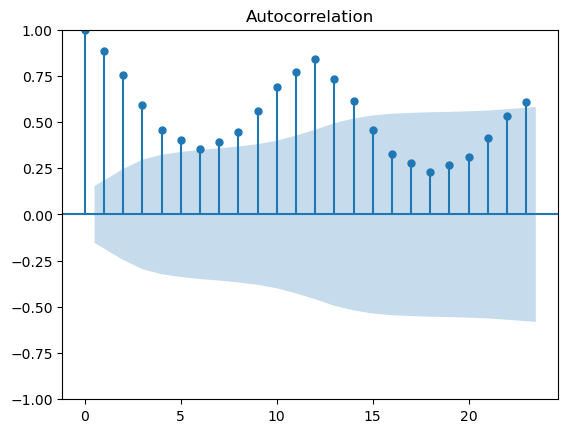

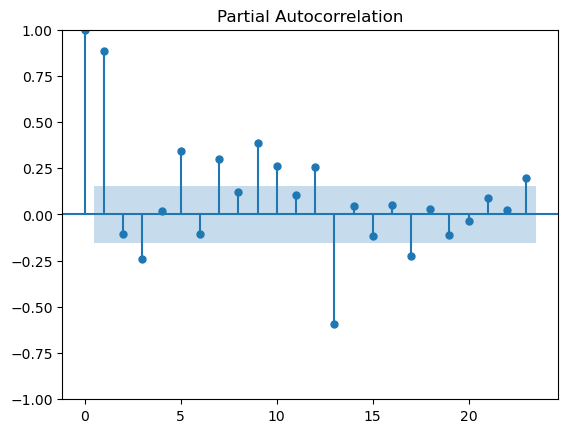

In [2]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

data.plot()
plot_acf(data).show()
plot_pacf(data, method = "ywm").show()

print(adfuller(data))
print(acorr_ljungbox(data))

([<matplotlib.axis.XTick at 0x2668ea190a0>,
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

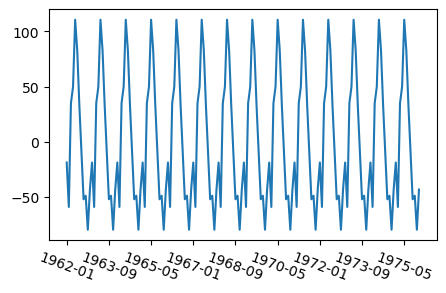

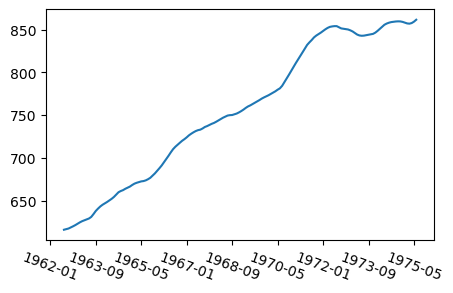

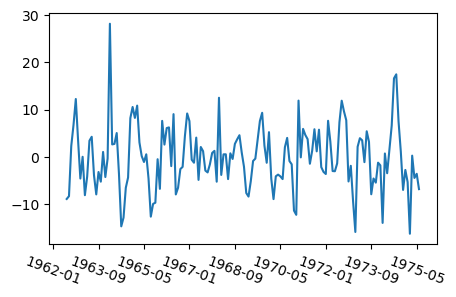

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
d = pd.read_csv('milkproduction.csv', index_col = 'Month')
time = d.index
d = seasonal_decompose(d, model = 'addictive', period = 12)
plt.figure(figsize = (5, 3), dpi = 100)
plt.plot(d.seasonal)
plt.xticks([time[x] for x in range(len(time)) if x % 20 == 0], rotation = -20)

plt.figure(figsize = (5, 3), dpi = 100)
plt.plot(d.trend)
plt.xticks([time[x] for x in range(len(time)) if x % 20 == 0], rotation = -20)

plt.figure(figsize = (5, 3), dpi = 100)
plt.plot(d.resid)
plt.xticks([time[x] for x in range(len(time)) if x % 20 == 0], rotation = -20)

第1次差分	acf:-2.363045052505378	{'1%': -3.4753253063120644, '5%': -2.881274703275226, '10%': -2.5772928360116873}
第2次差分	acf:-14.684106248847039	{'1%': -3.4753253063120644, '5%': -2.881274703275226, '10%': -2.5772928360116873}
         production
Month              
1962-03       107.0
1962-04       -63.0
1962-05        55.0
1962-06      -101.0
1962-07       -27.0
(-14.684106248847039, 3.1227365805567762e-27, 11, 148, {'1%': -3.4753253063120644, '5%': -2.881274703275226, '10%': -2.5772928360116873}, 1061.6087065181332)
       lb_stat     lb_pvalue
1    61.755290  3.889052e-15
2    76.973873  1.929016e-17
3    77.577785  1.015081e-16
4    90.599427  9.821157e-19
5   114.344067  4.942929e-23
6   149.024622  1.243931e-29
7   173.380987  4.860808e-34
8   185.899480  5.930959e-36
9   186.409141  2.320563e-35
10  200.474253  1.285212e-37


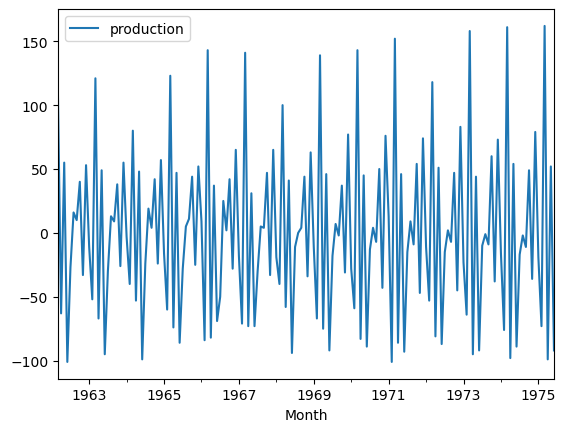

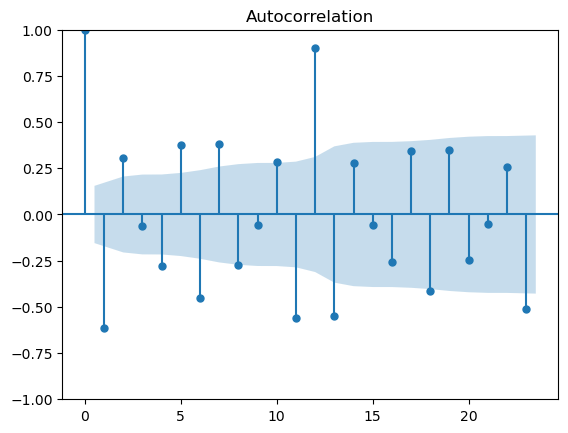

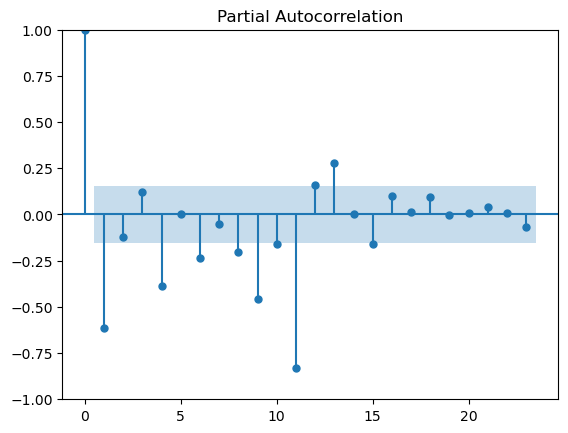

In [4]:
def check_smooth(data):
    data = data.diff().dropna()
    return data

d = acf = Assuming = 0
while(acf >= Assuming):
    d+=1
    data = check_smooth(data)
    acf, Assuming = adfuller(data)[0], adfuller(data)[4]["1%"]
    print(f"第{d}次差分\tacf:{acf}\t{adfuller(data)[4]}")

print(data.head())

data.plot()
plot_acf(data).show()
plot_pacf(data, method="ywm").show()

print(adfuller(data))
print(acorr_ljungbox(data))

In [5]:
from statsmodels.tsa.arima.model import ARIMA
from functools import reduce
from itertools import product

#test_bic = lambda x, y: x if ARIMA(data, order = (x[0], d, x[1])).fit().bic < ARIMA(data, order = (y[0], d, y[1])).fit().bic else y
#p, q = reduce(test_bic ,list(product(range(len(data)//10 + 1), repeat = 2)))
#print(p ,q)

In [6]:
warnings.filterwarnings("ignore")
data = pd.read_csv('milkproduction.csv', index_col='Month')
pmax = len(data)//10  # 一般阶数不超过length/10
qmax = len(data)//10  # 一般阶数不超过length/10

bic_matrix = []  # BIC矩阵
for p in range(pmax+1):
  tmp = []
  for q in range(qmax+1):
    try:  # 存在部分报错，所以用try来跳过报错。
      tmp.append(ARIMA(data, order = (p, d, q)).fit().bic)
    except:
      tmp.append(None)
  bic_matrix.append(tmp)

bic_matrix = pd.DataFrame(bic_matrix)  # 从中可以找出最小值

p, q = bic_matrix.stack().idxmin()  # 先用stack展平，然后用idxmin找出最小值位置。
print('BIC最小的p值和q值为: %s, %s' %(p, q)) 

In [ ]:
data = pd.read_csv('milkproduction.csv', index_col = 'Month')
data.index = pd.DatetimeIndex(data.index).to_period('M')
data, test_set = data.truncate(after = "1975-06"), data.truncate(before = "1975-07")

warnings.filterwarnings('ignore')
model = ARIMA(data, order = (4, 2, 7)).fit()
print(model.summary())
predict = model.predict(str(test_set.index[0]), str(test_set.index[-1]))
predict = pd.DataFrame(predict.values, columns = ['pred'])

d = test_set
d['pred'] = predict['pred'].values
d['error'] = d['pred'] - d['production']
print(d)

                               SARIMAX Results                                
Dep. Variable:             production   No. Observations:                  162
Model:                 ARIMA(4, 2, 7)   Log Likelihood                -782.809
Date:                Sat, 10 Dec 2022   AIC                           1589.618
Time:                        14:13:28   BIC                           1626.520
Sample:                    01-31-1962   HQIC                          1604.602
                         - 06-30-1975                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6675      0.055    -12.184      0.000      -0.775      -0.560
ar.L2         -0.1390      0.102     -1.369      0.171      -0.338       0.060
ar.L3         -0.6370      0.079     -8.059      0.0